In [71]:
# ============================================================
# Bluestock Mutual Fund Analytics
# Day 3 — Exploratory Data Analysis
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Project paths
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", BASE_DIR)
print("Processed data directory:", PROCESSED_DIR)

Project directory: c:\Users\Abhinandhan\mutual-fund-project
Processed data directory: c:\Users\Abhinandhan\mutual-fund-project\data\processed


In [72]:
# ============================================================
# Load cleaned datasets
# ============================================================

fund_master = pd.read_csv(
    PROCESSED_DIR / "fund_master_cleaned.csv"
)

nav_history = pd.read_csv(
    PROCESSED_DIR / "nav_history_cleaned.csv",
    parse_dates=["date"]
)

transactions = pd.read_csv(
    PROCESSED_DIR / "investor_transactions_cleaned.csv",
    parse_dates=["transaction_date"]
)

performance = pd.read_csv(
    PROCESSED_DIR / "scheme_performance_cleaned.csv"
)

aum = pd.read_csv(
    PROCESSED_DIR / "aum_by_fund_house_cleaned.csv",
    parse_dates=["date"]
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [73]:
# ============================================================
# Dataset overview
# ============================================================

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "Transactions": transactions,
    "Performance": performance,
    "AUM": aum
}

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("Missing values:", df.isna().sum().sum())


Fund Master
Shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
Missing values: 0

NAV History
Shape: (64320, 3)
Columns: ['amfi_code', 'date', 'nav']
Missing values: 0

Transactions
Shape: (32778, 13)
Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
Missing values: 0

Performance
Shape: (40, 19)
Columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
Missing values: 0

AUM
Shape: (90,

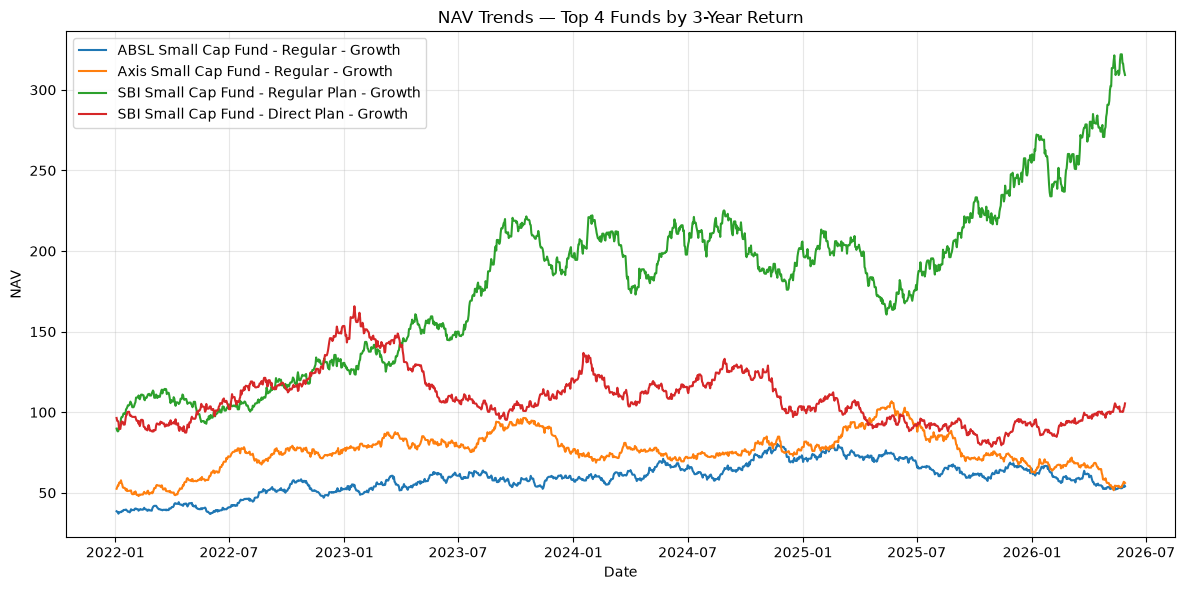

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_nav_trends_top4.png


In [74]:
# ============================================================
# Chart 1 — NAV Trends of Top 4 Funds
# ============================================================

# Select top 4 funds by 3-year return
top_4_codes = (
    performance
    .sort_values("return_3yr_pct", ascending=False)
    .head(4)["amfi_code"]
    .tolist()
)

# Add scheme names to NAV history
nav_chart = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Keep only the top 4 funds
nav_chart = nav_chart[
    nav_chart["amfi_code"].isin(top_4_codes)
]

# Create chart
plt.figure(figsize=(12, 6))

for scheme in nav_chart["scheme_name"].unique():

    fund_data = nav_chart[
        nav_chart["scheme_name"] == scheme
    ].sort_values("date")

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=scheme
    )

plt.title("NAV Trends — Top 4 Funds by 3-Year Return")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_nav_trends_top4.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

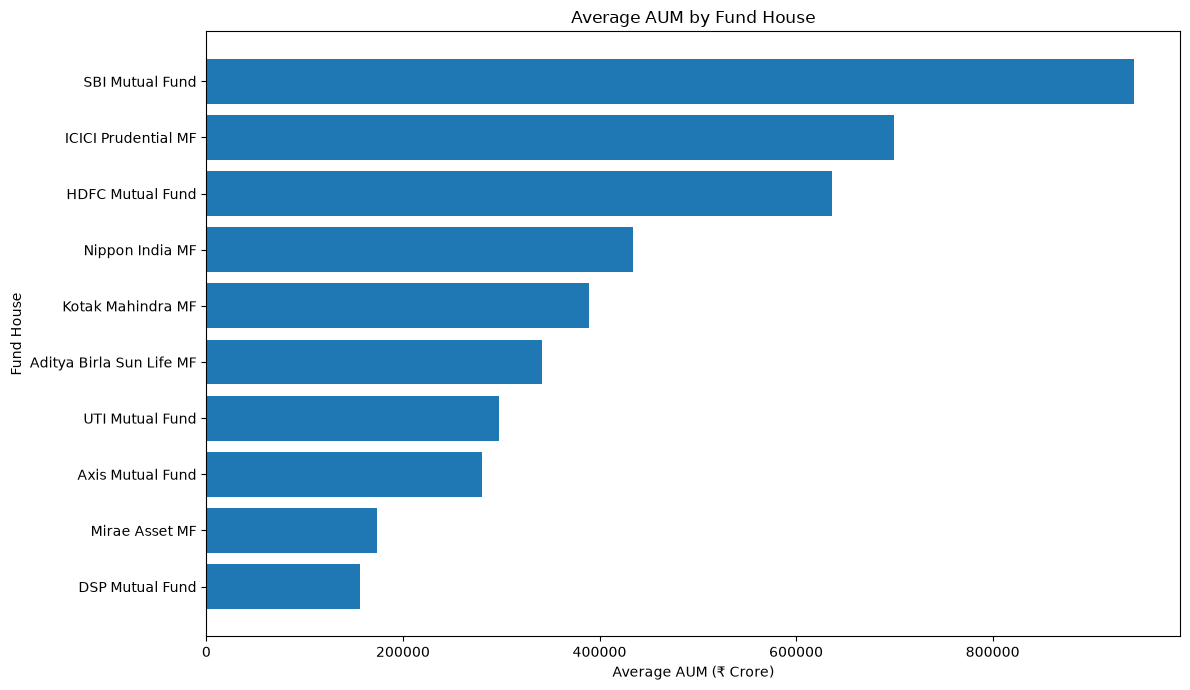

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_aum_by_fund_house.png


In [75]:
# ============================================================
# Chart 2 — AUM by Fund House
# ============================================================

aum_by_house = (
    aum.groupby("fund_house")["aum_crore"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))

plt.barh(
    aum_by_house.index,
    aum_by_house.values
)

plt.title("Average AUM by Fund House")
plt.xlabel("Average AUM (₹ Crore)")
plt.ylabel("Fund House")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_aum_by_fund_house.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

In [76]:
# ============================================================
# Load Monthly SIP Inflows
# ============================================================

sip = pd.read_csv(
    PROCESSED_DIR / "monthly_sip_inflows_cleaned.csv",
    parse_dates=["month"]
)

print("SIP dataset loaded successfully.")
print("Shape:", sip.shape)
print("\nColumns:")
print(sip.columns.tolist())

display(sip.head())

SIP dataset loaded successfully.
Shape: (48, 6)

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


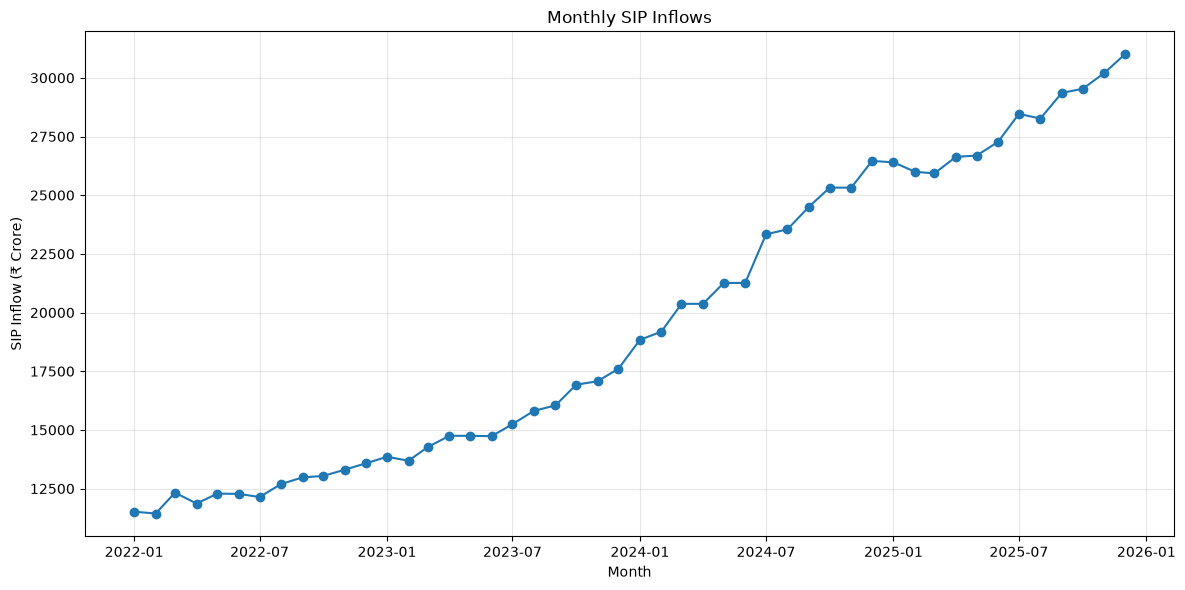

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_monthly_sip_inflows.png


In [77]:
# ============================================================
# Chart 3 — Monthly SIP Inflows
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_monthly_sip_inflows.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

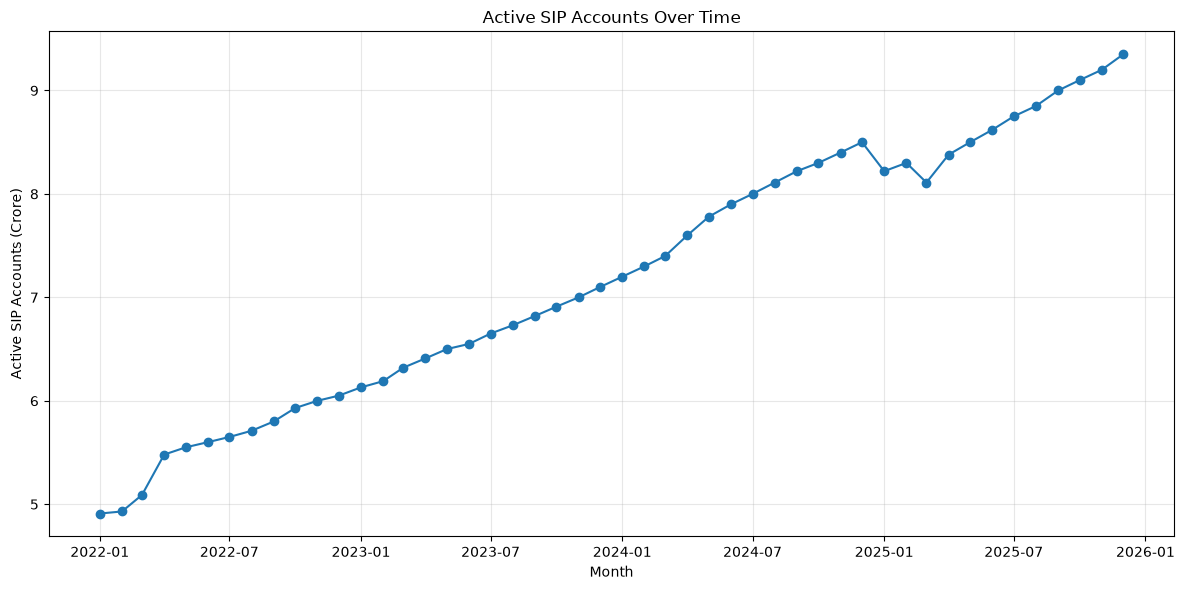

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_active_sip_accounts.png


In [78]:
# ============================================================
# Chart 4 — Active SIP Accounts
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    sip["month"],
    sip["active_sip_accounts_crore"],
    marker="o"
)

plt.title("Active SIP Accounts Over Time")
plt.xlabel("Month")
plt.ylabel("Active SIP Accounts (Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_active_sip_accounts.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

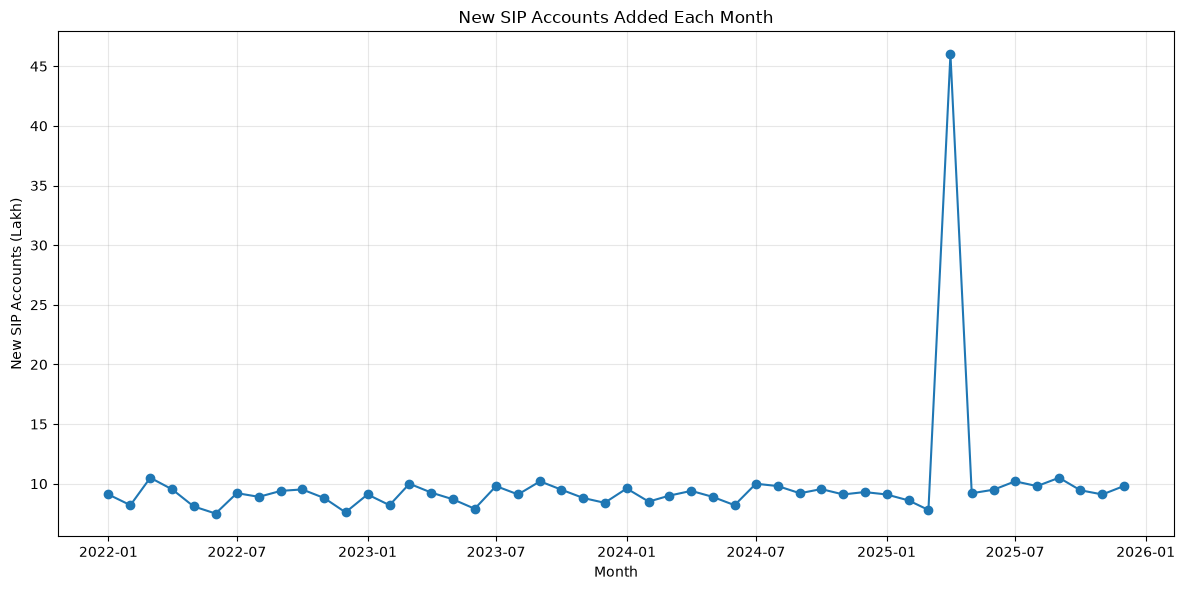

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_new_sip_accounts.png


In [79]:
# ============================================================
# Chart 5 — New SIP Accounts
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    sip["month"],
    sip["new_sip_accounts_lakh"],
    marker="o"
)

plt.title("New SIP Accounts Added Each Month")
plt.xlabel("Month")
plt.ylabel("New SIP Accounts (Lakh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_new_sip_accounts.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

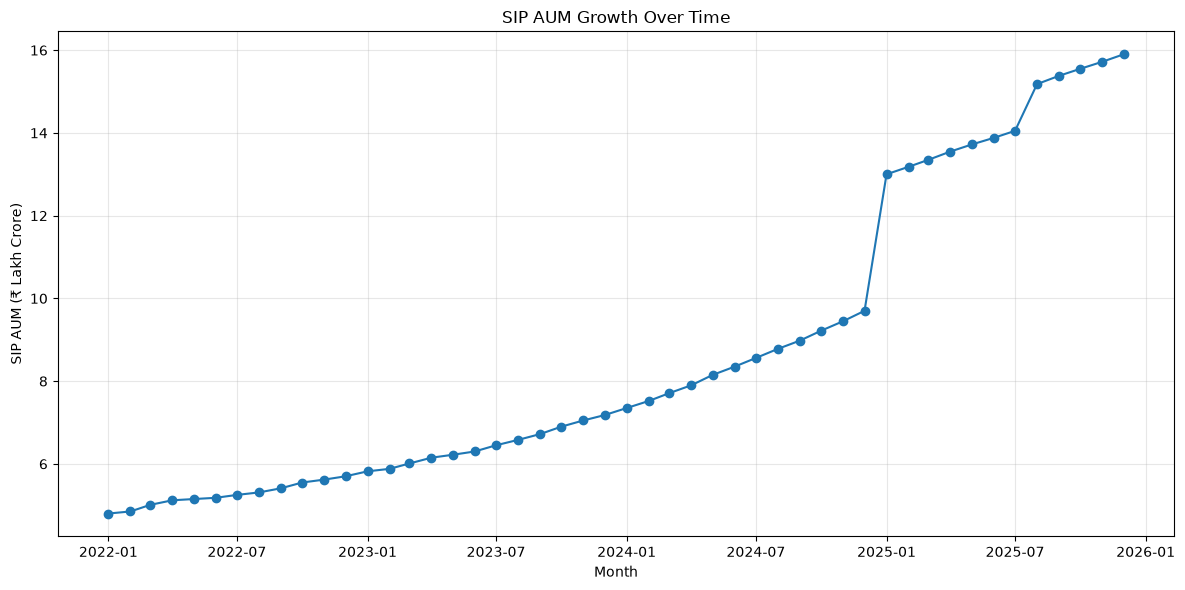

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_sip_aum_growth.png


In [80]:
# ============================================================
# Chart 6 — SIP AUM Growth
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    sip["month"],
    sip["sip_aum_lakh_crore"],
    marker="o"
)

plt.title("SIP AUM Growth Over Time")
plt.xlabel("Month")
plt.ylabel("SIP AUM (₹ Lakh Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_sip_aum_growth.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

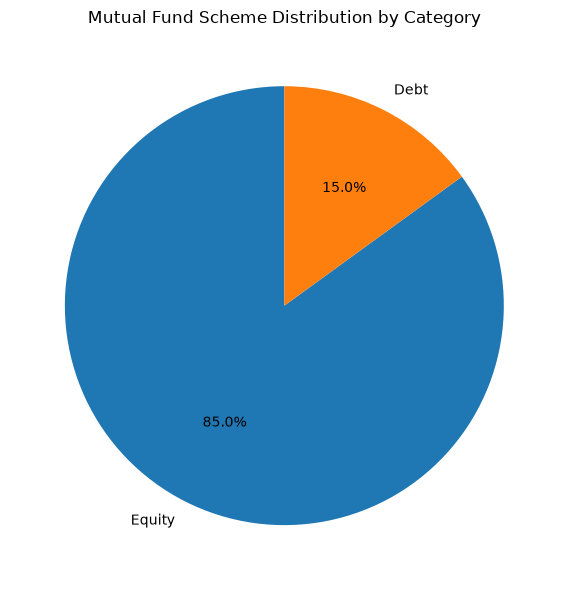

Category counts:
category
Equity    34
Debt       6
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_fund_category_distribution.png


In [81]:
# ============================================================
# Chart 7 — Fund Category Distribution
# ============================================================

category_counts = (
    fund_master["category"]
    .value_counts()
)

plt.figure(figsize=(8, 6))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Mutual Fund Scheme Distribution by Category")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_fund_category_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Category counts:")
print(category_counts)

print("\nChart saved to:", chart_path)

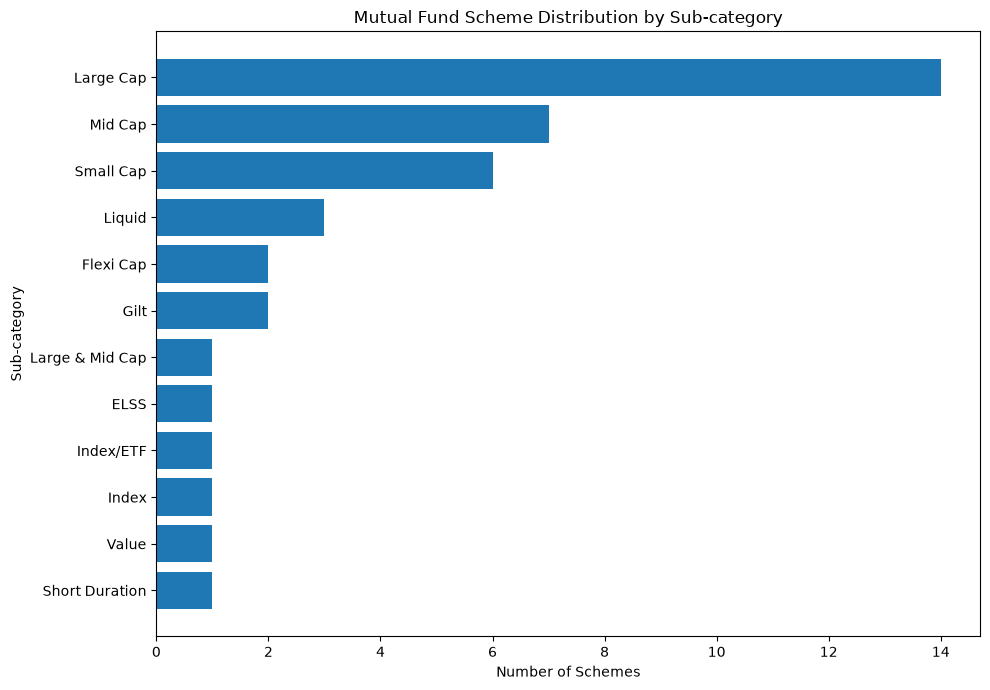

Sub-category counts:
sub_category
Short Duration      1
Value               1
Index               1
Index/ETF           1
ELSS                1
Large & Mid Cap     1
Gilt                2
Flexi Cap           2
Liquid              3
Small Cap           6
Mid Cap             7
Large Cap          14
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_fund_subcategory_distribution.png


In [82]:
# ============================================================
# Chart 8 — Fund Sub-category Distribution
# ============================================================

subcategory_counts = (
    fund_master["sub_category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    subcategory_counts.index,
    subcategory_counts.values
)

plt.title("Mutual Fund Scheme Distribution by Sub-category")
plt.xlabel("Number of Schemes")
plt.ylabel("Sub-category")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_fund_subcategory_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Sub-category counts:")
print(subcategory_counts)

print("\nChart saved to:", chart_path)

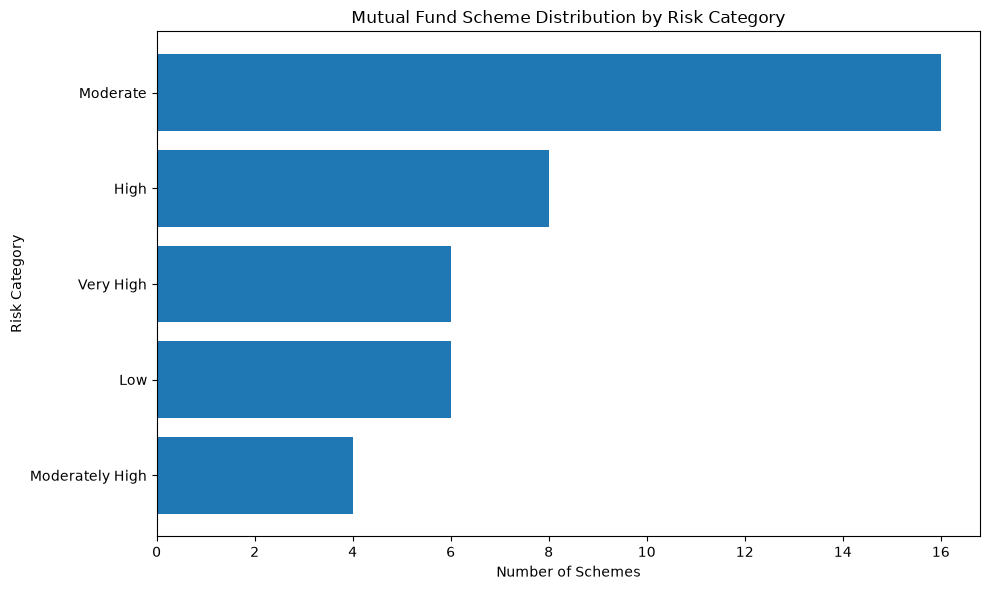

Risk category counts:
risk_category
Moderately High     4
Low                 6
Very High           6
High                8
Moderate           16
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_risk_category_distribution.png


In [83]:
# ============================================================
# Chart 9 — Risk Category Distribution
# ============================================================

risk_counts = (
    fund_master["risk_category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    risk_counts.index,
    risk_counts.values
)

plt.title("Mutual Fund Scheme Distribution by Risk Category")
plt.xlabel("Number of Schemes")
plt.ylabel("Risk Category")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_risk_category_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Risk category counts:")
print(risk_counts)

print("\nChart saved to:", chart_path)

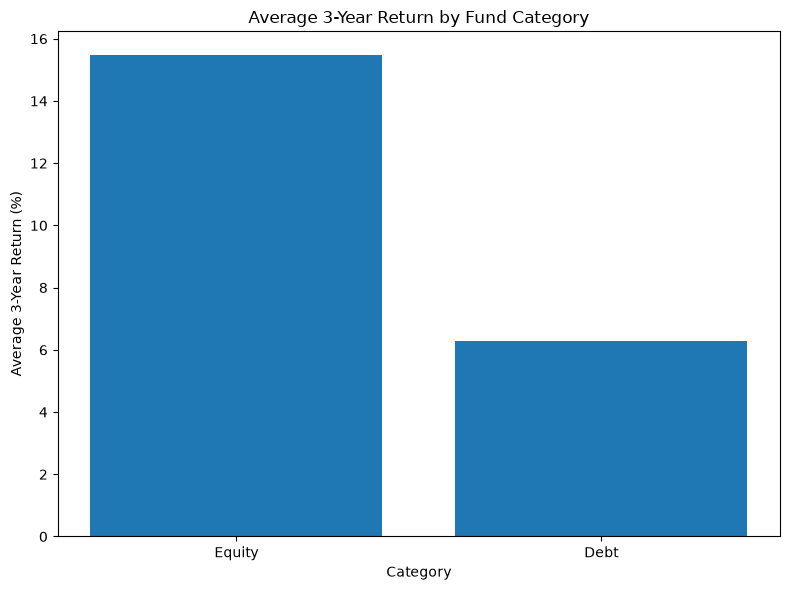

Average 3-year returns by category:
category
Equity    15.46
Debt       6.29
Name: return_3yr_pct, dtype: float64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_3yr_return_by_category.png


In [84]:
# ============================================================
# Chart 10 — Average 3-Year Return by Category
# ============================================================

# Get the true Equity/Debt category from Fund Master
category_lookup = fund_master[
    ["amfi_code", "category"]
].drop_duplicates("amfi_code")

# Merge with performance
category_performance = performance[
    ["amfi_code", "return_3yr_pct"]
].merge(
    category_lookup,
    on="amfi_code",
    how="left"
)

# Calculate average 3-year return
category_returns = (
    category_performance
    .groupby("category")["return_3yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

plt.bar(
    category_returns.index,
    category_returns.values
)

plt.title("Average 3-Year Return by Fund Category")
plt.xlabel("Category")
plt.ylabel("Average 3-Year Return (%)")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_3yr_return_by_category.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Average 3-year returns by category:")
print(category_returns.round(2))

print("\nChart saved to:", chart_path)

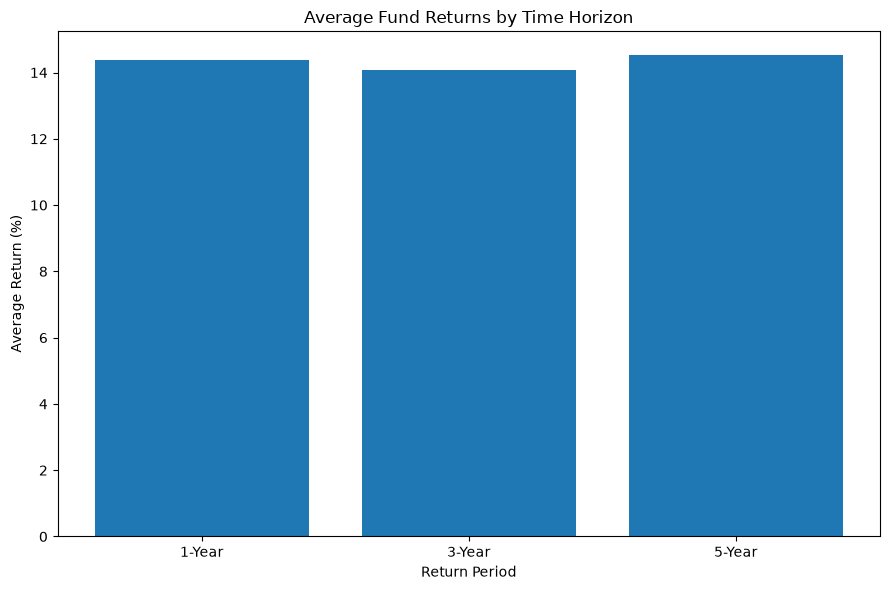

Average returns:
1-Year    14.38
3-Year    14.09
5-Year    14.52
dtype: float64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_average_returns_by_horizon.png


In [85]:
# ============================================================
# Chart 11 — Average Returns by Time Horizon
# ============================================================

average_returns = pd.Series({
    "1-Year": performance["return_1yr_pct"].mean(),
    "3-Year": performance["return_3yr_pct"].mean(),
    "5-Year": performance["return_5yr_pct"].mean()
})

plt.figure(figsize=(9, 6))

plt.bar(
    average_returns.index,
    average_returns.values
)

plt.title("Average Fund Returns by Time Horizon")
plt.xlabel("Return Period")
plt.ylabel("Average Return (%)")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_average_returns_by_horizon.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Average returns:")
print(average_returns.round(2))

print("\nChart saved to:", chart_path)

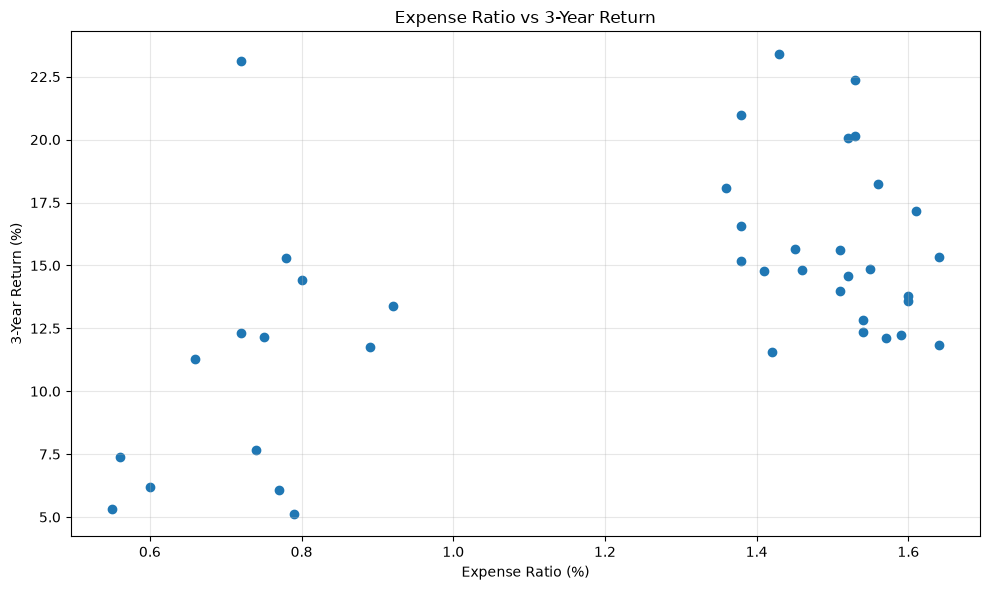

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_expense_ratio_vs_3yr_return.png


In [86]:
# ============================================================
# Chart 12 — Expense Ratio vs 3-Year Return
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    performance["expense_ratio_pct"],
    performance["return_3yr_pct"]
)

plt.title("Expense Ratio vs 3-Year Return")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("3-Year Return (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_expense_ratio_vs_3yr_return.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

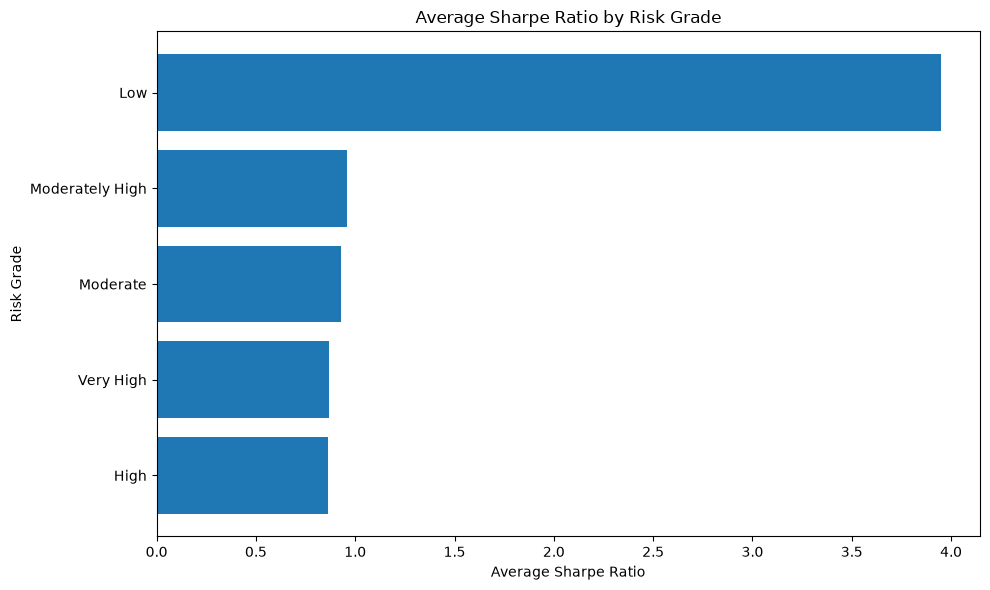

Average Sharpe ratio by risk grade:
risk_grade
High               0.86
Very High          0.87
Moderate           0.93
Moderately High    0.96
Low                3.95
Name: sharpe_ratio, dtype: float64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_sharpe_by_risk_grade.png


In [87]:
# ============================================================
# Chart 13 — Average Sharpe Ratio by Risk Category
# ============================================================

sharpe_by_risk = (
    performance
    .groupby("risk_grade")["sharpe_ratio"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    sharpe_by_risk.index,
    sharpe_by_risk.values
)

plt.title("Average Sharpe Ratio by Risk Grade")
plt.xlabel("Average Sharpe Ratio")
plt.ylabel("Risk Grade")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_sharpe_by_risk_grade.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Average Sharpe ratio by risk grade:")
print(sharpe_by_risk.round(2))

print("\nChart saved to:", chart_path)

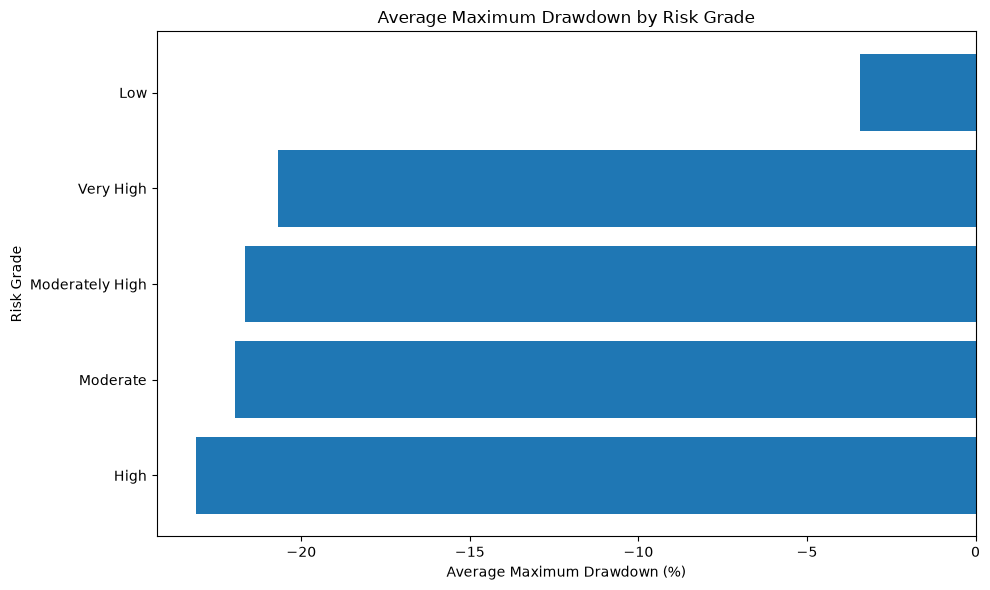

Average maximum drawdown by risk grade:
risk_grade
High              -23.13
Moderate          -21.97
Moderately High   -21.67
Very High         -20.68
Low                -3.44
Name: max_drawdown_pct, dtype: float64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_max_drawdown_by_risk_grade.png


In [88]:
# ============================================================
# Chart 14 — Average Maximum Drawdown by Risk Grade
# ============================================================

drawdown_by_risk = (
    performance
    .groupby("risk_grade")["max_drawdown_pct"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    drawdown_by_risk.index,
    drawdown_by_risk.values
)

plt.title("Average Maximum Drawdown by Risk Grade")
plt.xlabel("Average Maximum Drawdown (%)")
plt.ylabel("Risk Grade")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_max_drawdown_by_risk_grade.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Average maximum drawdown by risk grade:")
print(drawdown_by_risk.round(2))

print("\nChart saved to:", chart_path)

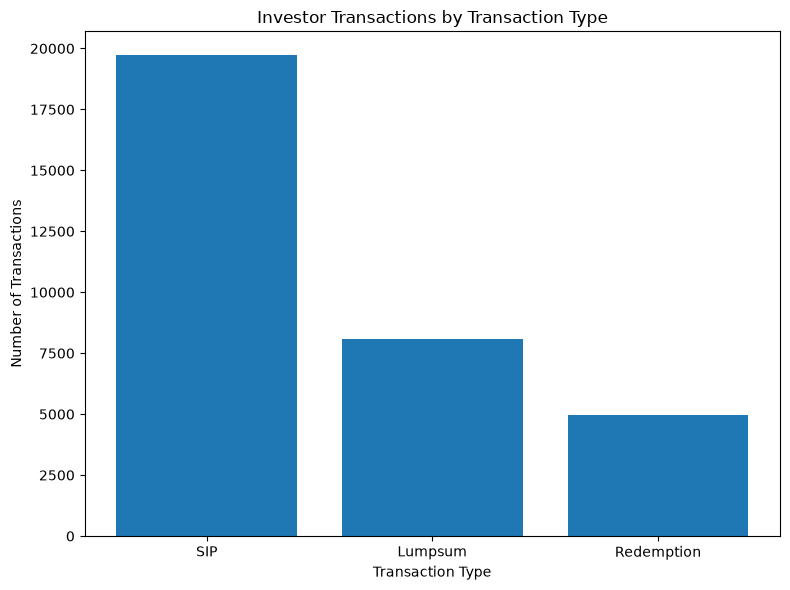

Transaction counts:
transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_transaction_type_distribution.png


In [89]:
# ============================================================
# Chart 15 — Transaction Type Distribution
# ============================================================

transaction_counts = (
    transactions["transaction_type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

plt.bar(
    transaction_counts.index,
    transaction_counts.values
)

plt.title("Investor Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_transaction_type_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Transaction counts:")
print(transaction_counts)

print("\nChart saved to:", chart_path)

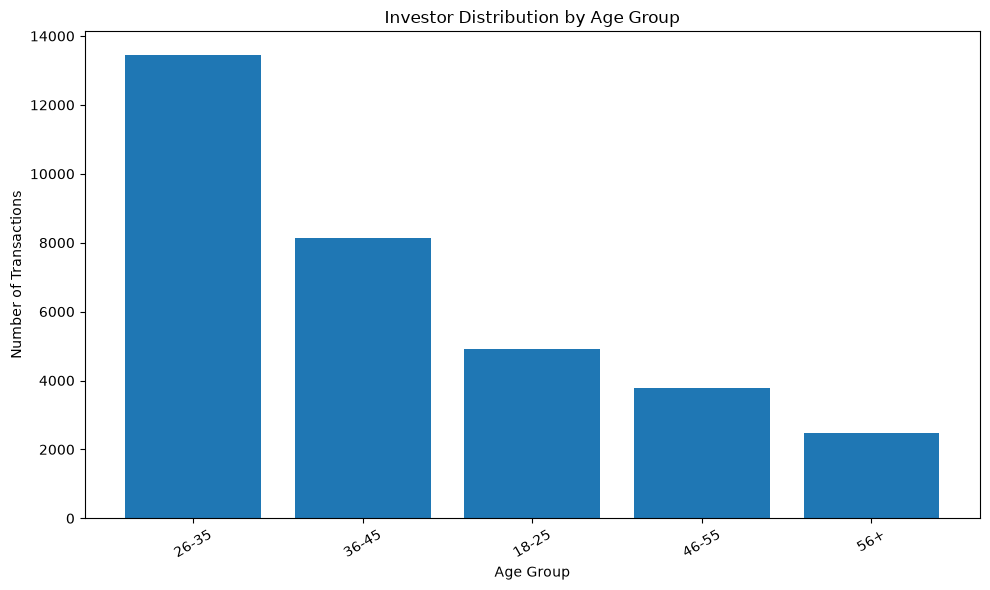

Transactions by age group:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_investor_age_group.png


In [90]:
# ============================================================
# Chart 16 — Investor Age Group Distribution
# ============================================================

age_counts = (
    transactions["age_group"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    age_counts.index,
    age_counts.values
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_investor_age_group.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Transactions by age group:")
print(age_counts)

print("\nChart saved to:", chart_path)

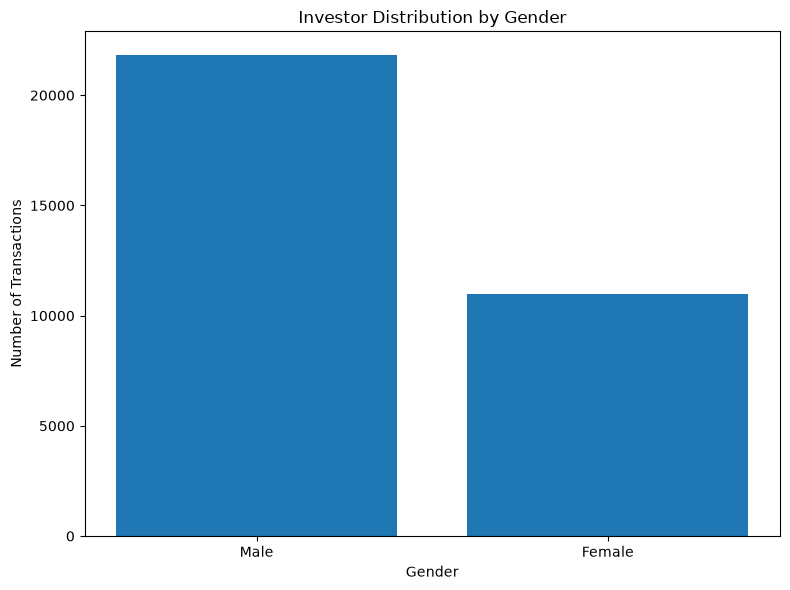

Transactions by gender:
gender
Male      21809
Female    10969
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_investor_gender.png


In [91]:
# ============================================================
# Chart 17 — Investor Gender Distribution
# ============================================================

gender_counts = (
    transactions["gender"]
    .value_counts()
)

plt.figure(figsize=(8, 6))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Investor Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_investor_gender.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Transactions by gender:")
print(gender_counts)

print("\nChart saved to:", chart_path)

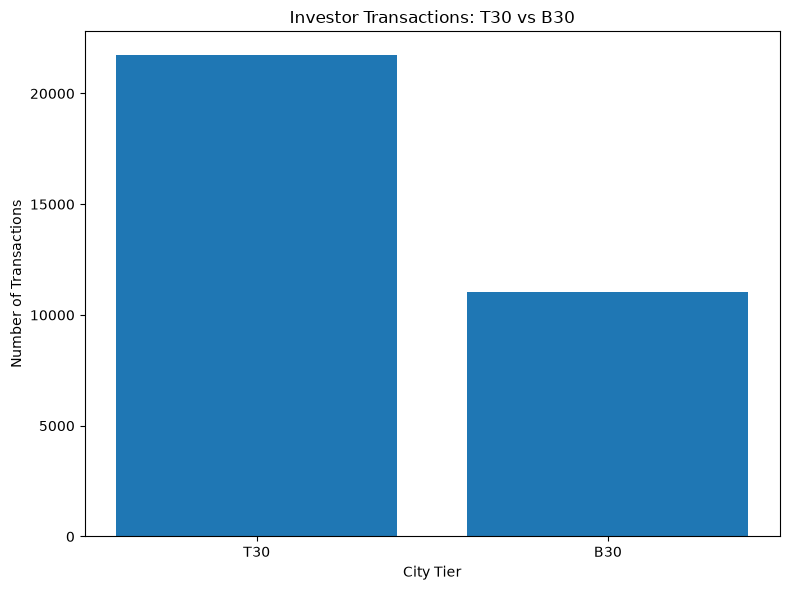

Transactions by city tier:
city_tier
T30    21719
B30    11059
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_t30_b30_transactions.png


In [92]:
# ============================================================
# Chart 18 — T30 vs B30 Investor Transactions
# ============================================================

city_tier_counts = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(8, 6))

plt.bar(
    city_tier_counts.index,
    city_tier_counts.values
)

plt.title("Investor Transactions: T30 vs B30")
plt.xlabel("City Tier")
plt.ylabel("Number of Transactions")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_t30_b30_transactions.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Transactions by city tier:")
print(city_tier_counts)

print("\nChart saved to:", chart_path)

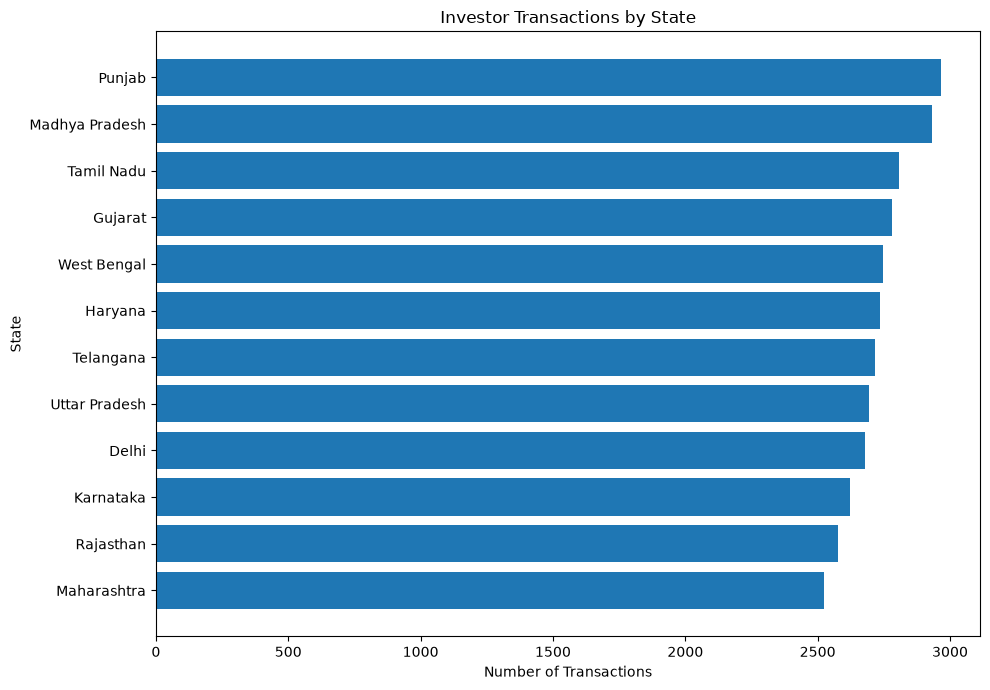

Transactions by state:
state
Maharashtra       2524
Rajasthan         2577
Karnataka         2621
Delhi             2677
Uttar Pradesh     2695
Telangana         2718
Haryana           2736
West Bengal       2748
Gujarat           2780
Tamil Nadu        2806
Madhya Pradesh    2931
Punjab            2965
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_transactions_by_state.png


In [93]:
# ============================================================
# Chart 19 — Investor Transactions by State
# ============================================================

state_counts = (
    transactions["state"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    state_counts.index,
    state_counts.values
)

plt.title("Investor Transactions by State")
plt.xlabel("Number of Transactions")
plt.ylabel("State")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_transactions_by_state.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Transactions by state:")
print(state_counts)

print("\nChart saved to:", chart_path)

<Figure size 800x600 with 0 Axes>

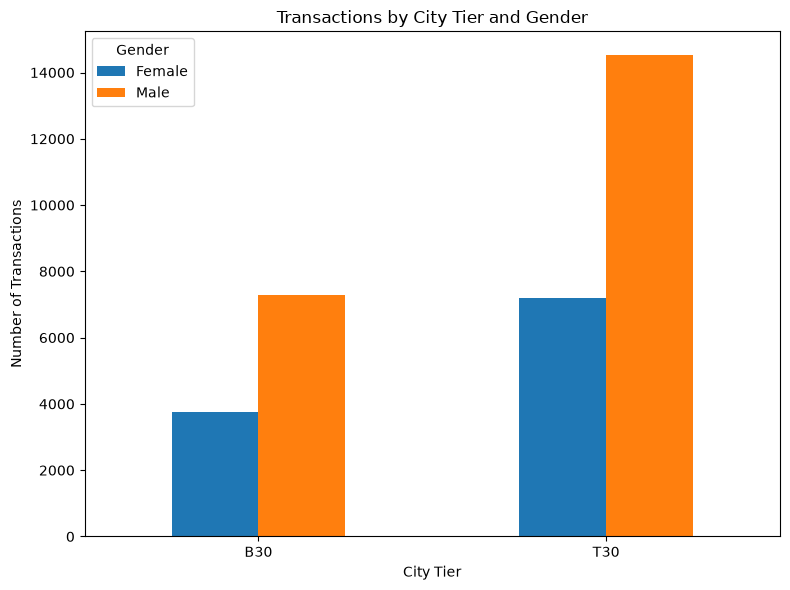

Transactions by city tier and gender:
gender     Female   Male
city_tier               
B30          3767   7292
T30          7202  14517

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_city_tier_gender.png


In [94]:
# ============================================================
# Chart 20 — City Tier and Gender Distribution
# ============================================================

tier_gender = (
    transactions
    .groupby(["city_tier", "gender"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(8, 6))

tier_gender.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Transactions by City Tier and Gender")
plt.xlabel("City Tier")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_city_tier_gender.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Transactions by city tier and gender:")
print(tier_gender)

print("\nChart saved to:", chart_path)

In [95]:
# ============================================================
# Chart 21 — Performance Metrics Correlation Heatmap
# ============================================================

correlation_columns = [
    "return_1y_pct",
    "return_3y_pct",
    "return_5y_pct",
    "volatility_pct",
    "sharpe_ratio",
    "sortino_ratio",
    "max_drawdown_pct"
]

corr_matrix = performance[correlation_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Fund Performance Metrics")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_performance_correlation_heatmap.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Correlation matrix:")
print(corr_matrix)

print("\nChart saved to:", chart_path)

KeyError: "['return_1y_pct', 'return_3y_pct', 'return_5y_pct', 'volatility_pct'] not in index"

In [ ]:
print("Performance columns:")
print(performance.columns.tolist())

Performance columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


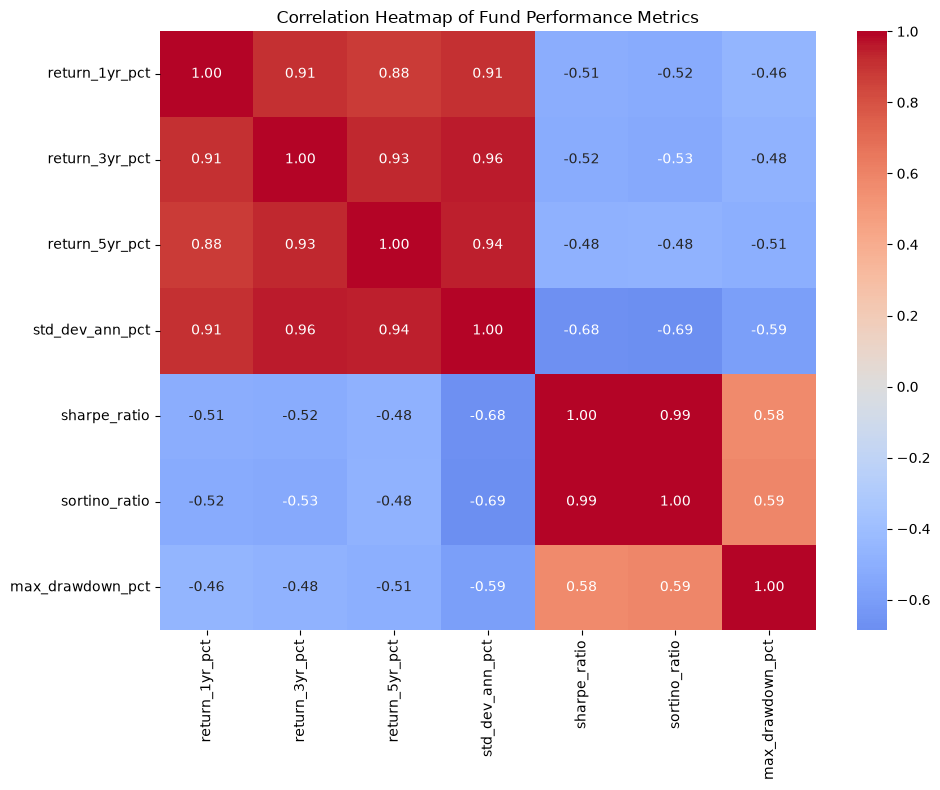

Correlation matrix:
                  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
return_1yr_pct          1.000000        0.910491        0.879870   
return_3yr_pct          0.910491        1.000000        0.929076   
return_5yr_pct          0.879870        0.929076        1.000000   
std_dev_ann_pct         0.907561        0.956132        0.940751   
sharpe_ratio           -0.508997       -0.519123       -0.483935   
sortino_ratio          -0.521809       -0.531099       -0.481465   
max_drawdown_pct       -0.457619       -0.479871       -0.507809   

                  std_dev_ann_pct  sharpe_ratio  sortino_ratio  \
return_1yr_pct           0.907561     -0.508997      -0.521809   
return_3yr_pct           0.956132     -0.519123      -0.531099   
return_5yr_pct           0.940751     -0.483935      -0.481465   
std_dev_ann_pct          1.000000     -0.679069      -0.686042   
sharpe_ratio            -0.679069      1.000000       0.991099   
sortino_ratio           -0.686042      

In [ ]:
# ============================================================
# Chart 21 — Performance Metrics Correlation Heatmap
# ============================================================

correlation_columns = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "std_dev_ann_pct",
    "sharpe_ratio",
    "sortino_ratio",
    "max_drawdown_pct"
]

corr_matrix = performance[correlation_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Fund Performance Metrics")
plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_performance_correlation_heatmap.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Correlation matrix:")
print(corr_matrix)

print("\nChart saved to:", chart_path)

In [ ]:
# ============================================================
# EDA — 10 Key Findings
# ============================================================

findings = [
    "1. The fund universe contains 40 schemes across 10 fund houses, with Equity representing 34 schemes (85%) and Debt representing 6 schemes (15%).",

    "2. Large Cap is the largest sub-category with 14 schemes, followed by Mid Cap with 7 and Small Cap with 6.",

    "3. SBI has the highest average AUM among the fund houses in the dataset, followed by ICICI Prudential and HDFC.",

    "4. Monthly SIP inflows show a strong upward trend from approximately ₹11,500 crore in early 2022 to above ₹30,000 crore by the end of 2025.",

    "5. Active SIP accounts increased substantially from approximately 4.9 crore to around 9.3 crore over the analysis period.",

    "6. Equity funds generated substantially higher average returns than Debt funds: approximately 15.46% versus 6.29% over the 3-year horizon.",

    "7. The investor transaction dataset is dominated by SIP transactions, with 19,716 SIP transactions compared with 8,095 Lumpsum and 4,967 Redemption transactions.",

    "8. T30 cities account for 21,719 transactions (66.3%), compared with 11,059 transactions (33.7%) from B30 cities.",

    "9. Male investors account for 21,809 transactions (66.5%), while female investors account for 10,969 transactions (33.5%). The gender mix is broadly similar across T30 and B30 cities.",

    "10. Performance metrics show strong relationships: 3-year returns correlate 0.93 with 5-year returns and 0.96 with annualized volatility, while Sharpe and Sortino ratios are almost perfectly correlated at 0.99."
]

for finding in findings:
    print(finding)

# Save findings to report
findings_path = REPORTS_DIR / "eda_key_findings.txt"

with open(findings_path, "w", encoding="utf-8") as f:
    for finding in findings:
        f.write(finding + "\n")

print("\n10 EDA findings saved to:", findings_path)

1. The fund universe contains 40 schemes across 10 fund houses, with Equity representing 34 schemes (85%) and Debt representing 6 schemes (15%).
2. Large Cap is the largest sub-category with 14 schemes, followed by Mid Cap with 7 and Small Cap with 6.
3. SBI has the highest average AUM among the fund houses in the dataset, followed by ICICI Prudential and HDFC.
4. Monthly SIP inflows show a strong upward trend from approximately ₹11,500 crore in early 2022 to above ₹30,000 crore by the end of 2025.
5. Active SIP accounts increased substantially from approximately 4.9 crore to around 9.3 crore over the analysis period.
6. Equity funds generated substantially higher average returns than Debt funds: approximately 15.46% versus 6.29% over the 3-year horizon.
7. The investor transaction dataset is dominated by SIP transactions, with 19,716 SIP transactions compared with 8,095 Lumpsum and 4,967 Redemption transactions.
8. T30 cities account for 21,719 transactions (66.3%), compared with 11,0

In [ ]:
# ============================================================
# Step 91 — Inspect Remaining Datasets Required by Capstone
# ============================================================

raw_dir = BASE_DIR / "data" / "raw"

remaining_files = [
    "1788499984721-4b860901-05_category_inflows.csv",
    "1788499985036-da4a0c4a-06_industry_folio_count.csv",
    "1788499982117-e3d6ab98-09_portfolio_holdings.csv",
    "1788499982615-f9647ab2-10_benchmark_indices.csv"
]

for filename in remaining_files:
    path = raw_dir / filename

    print("\n" + "=" * 70)
    print(filename)
    print("=" * 70)

    df_temp = pd.read_csv(path)

    print("Shape:", df_temp.shape)
    print("Columns:", df_temp.columns.tolist())
    print(df_temp.head(3))


1788499984721-4b860901-05_category_inflows.csv
Shape: (144, 3)
Columns: ['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0
2  2024-04  Small Cap            3533.0

1788499985036-da4a0c4a-06_industry_folio_count.csv
Shape: (21, 6)
Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  

1788499982117-e3d6ab98-09_portfolio_holdings.

In [ ]:
# ============================================================
# Step 92 — Inspect Portfolio Holdings and Benchmark Data
# ============================================================

# Portfolio holdings
portfolio_path = raw_dir / "1788499982117-e3d6ab98-09_portfolio_holdings.csv"
portfolio = pd.read_csv(portfolio_path)

print("=" * 70)
print("PORTFOLIO HOLDINGS")
print("=" * 70)
print("Shape:", portfolio.shape)
print("Columns:", portfolio.columns.tolist())
print("\nUnique sectors:")
print(portfolio["sector"].value_counts())

print("\nFirst 5 rows:")
print(portfolio.head())


# Benchmark indices
benchmark_path = raw_dir / "1788499982615-f9647ab2-10_benchmark_indices.csv"
benchmark = pd.read_csv(benchmark_path)

print("\n" + "=" * 70)
print("BENCHMARK INDICES")
print("=" * 70)
print("Shape:", benchmark.shape)
print("Columns:", benchmark.columns.tolist())
print("\nIndex names:")
print(benchmark["index_name"].value_counts())

print("\nDate range:")
print(benchmark["date"].min(), "to", benchmark["date"].max())

print("\nFirst 5 rows:")
print(benchmark.head())

PORTFOLIO HOLDINGS
Shape: (322, 8)
Columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Unique sectors:
sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

First 5 rows:
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       

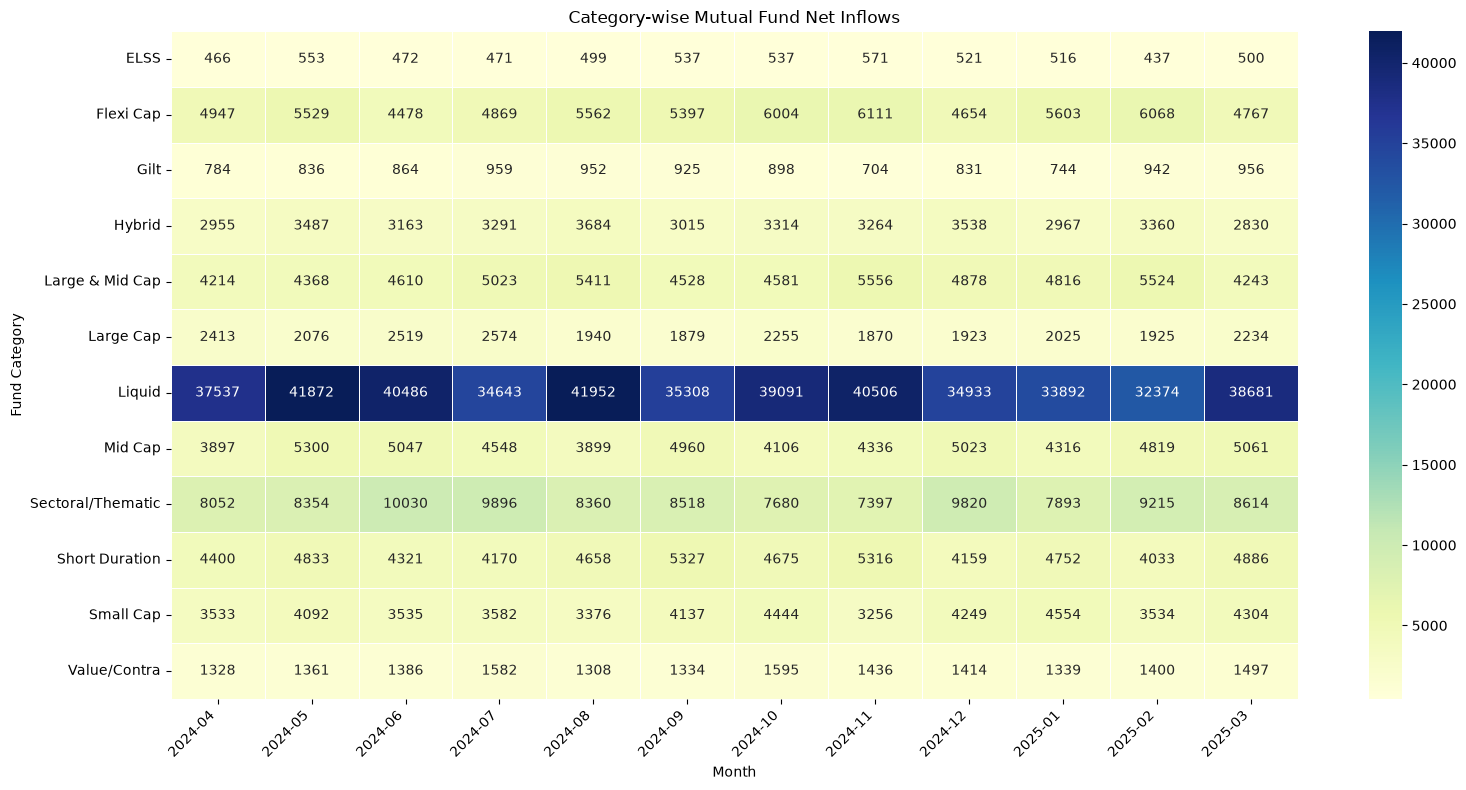

Category inflow matrix shape: (12, 12)

Categories:
['ELSS', 'Flexi Cap', 'Gilt', 'Hybrid', 'Large & Mid Cap', 'Large Cap', 'Liquid', 'Mid Cap', 'Sectoral/Thematic', 'Short Duration', 'Small Cap', 'Value/Contra']

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_category_inflow_heatmap.png


In [ ]:
# ============================================================
# Chart 22 — Category-wise Inflow Heatmap
# ============================================================

category_inflows = pd.read_csv(
    raw_dir / "1788499984721-4b860901-05_category_inflows.csv"
)

# Create month x category matrix
category_pivot = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    category_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Mutual Fund Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_category_inflow_heatmap.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Category inflow matrix shape:", category_pivot.shape)

print("\nCategories:")
print(category_pivot.index.tolist())

print("\nChart saved to:", chart_path)

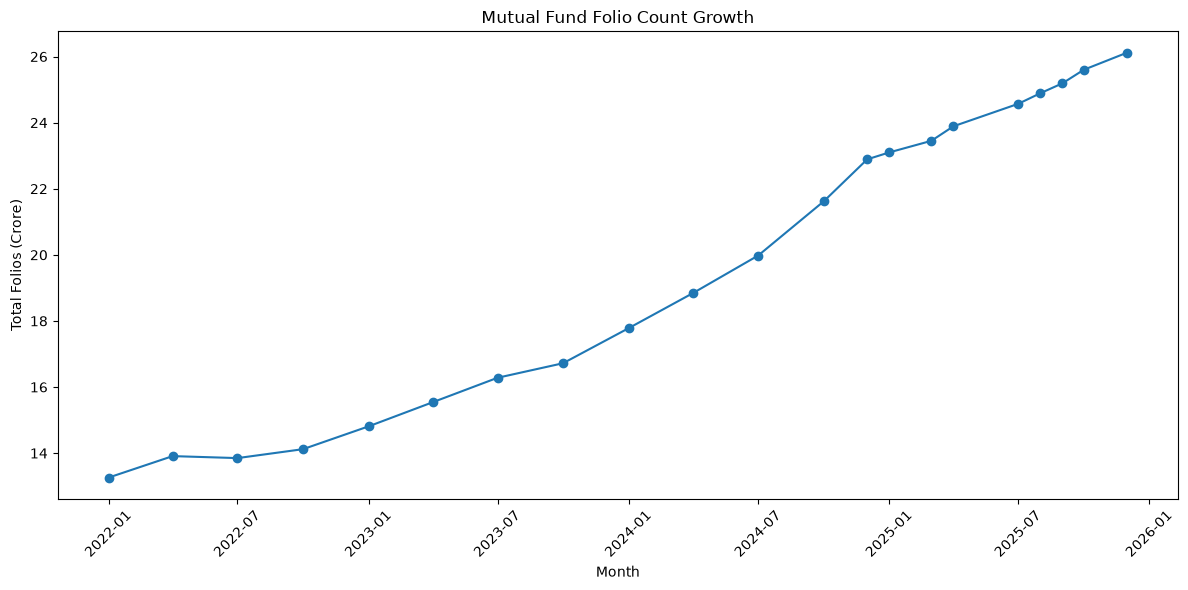

Folio count range:
2022-01 to 2025-12

Starting total folios: 13.26 crore
Ending total folios: 26.12 crore

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_folio_count_growth.png


In [ ]:
# ============================================================
# Chart 23 — Mutual Fund Folio Count Growth
# ============================================================

folio_path = raw_dir / "1788499985036-da4a0c4a-06_industry_folio_count.csv"

folio = pd.read_csv(folio_path)

folio["month"] = pd.to_datetime(folio["month"])

folio = folio.sort_values("month")

plt.figure(figsize=(12, 6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_folio_count_growth.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Folio count range:")
print(
    folio["month"].min().strftime("%Y-%m"),
    "to",
    folio["month"].max().strftime("%Y-%m")
)

print("\nStarting total folios:",
      folio.iloc[0]["total_folios_crore"], "crore")

print("Ending total folios:",
      folio.iloc[-1]["total_folios_crore"], "crore")

print("\nChart saved to:", chart_path)

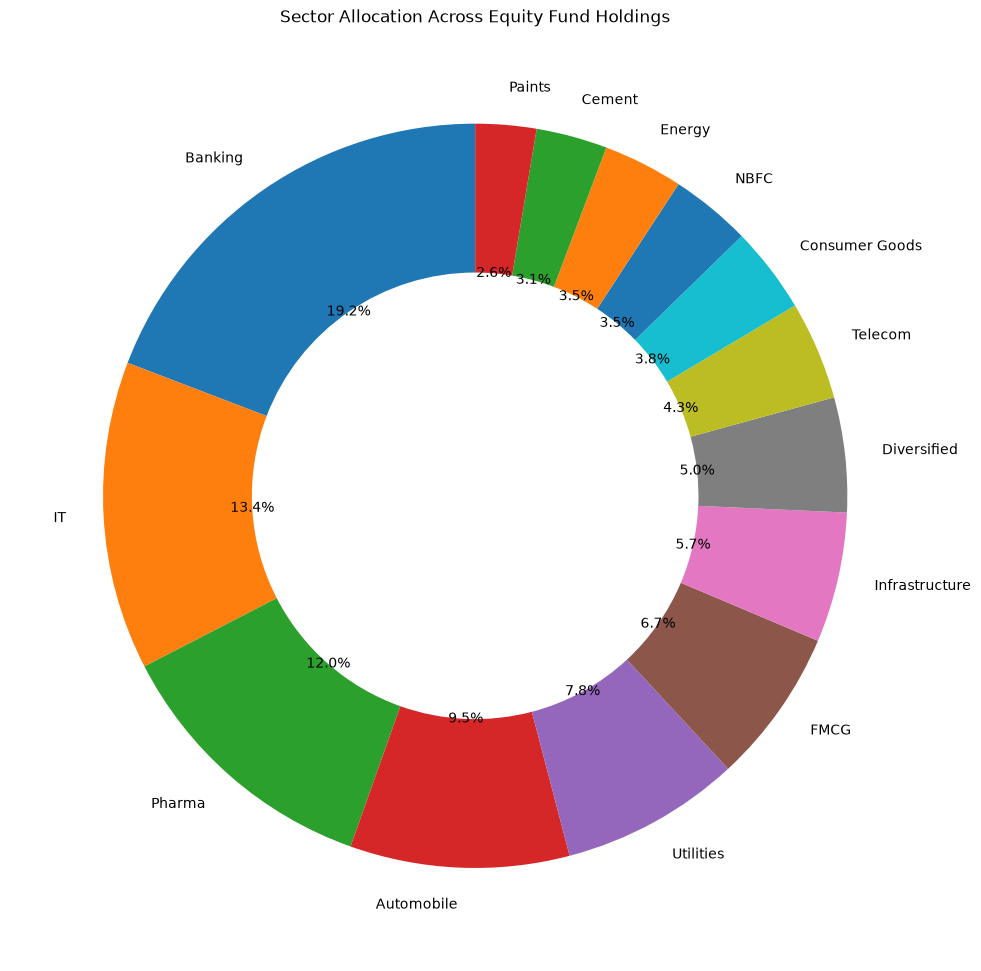

Sector allocation:
sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

Total sector weight: 3399.9900000000002

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_sector_allocation_donut.png


In [ ]:
# ============================================================
# Chart 24 — Sector Allocation Across Equity Fund Holdings
# ============================================================

sector_weights = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 10))

plt.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Sector Allocation Across Equity Fund Holdings")

plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_sector_allocation_donut.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Sector allocation:")
print(sector_weights)

print("\nTotal sector weight:", sector_weights.sum())

print("\nChart saved to:", chart_path)

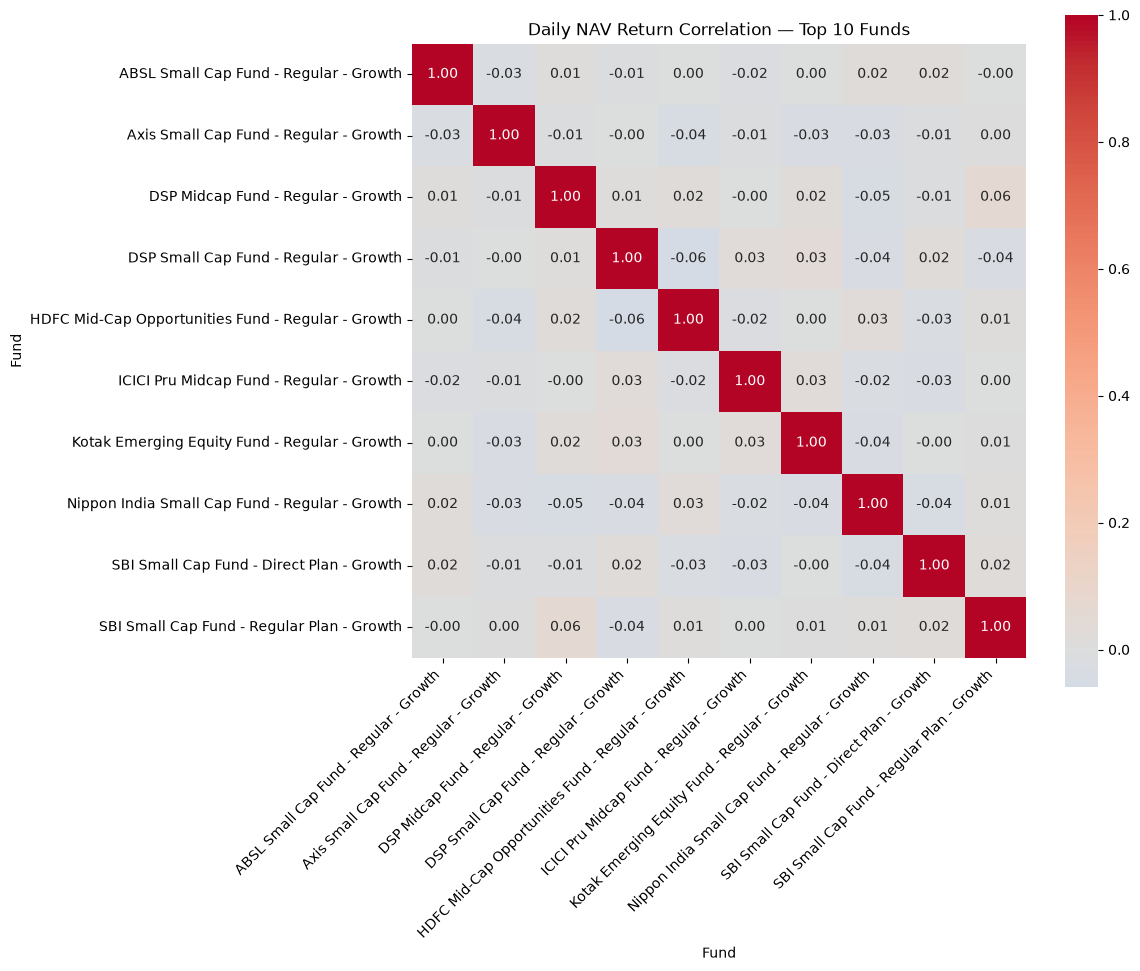

Selected funds:
119598 - SBI Small Cap Fund - Regular Plan - Growth
119599 - SBI Small Cap Fund - Direct Plan - Growth
101207 - ABSL Small Cap Fund - Regular - Growth
119095 - Axis Small Cap Fund - Regular - Growth
118634 - Nippon India Small Cap Fund - Regular - Growth
149324 - DSP Small Cap Fund - Regular - Growth
120842 - Kotak Emerging Equity Fund - Regular - Growth
120505 - ICICI Pru Midcap Fund - Regular - Growth
149323 - DSP Midcap Fund - Regular - Growth
100033 - HDFC Mid-Cap Opportunities Fund - Regular - Growth

Correlation matrix:
scheme_name                                         ABSL Small Cap Fund - Regular - Growth  \
scheme_name                                                                                  
ABSL Small Cap Fund - Regular - Growth                                               1.000   
Axis Small Cap Fund - Regular - Growth                                              -0.029   
DSP Midcap Fund - Regular - Growth                                          

In [ ]:
# ============================================================
# Chart 25 — NAV Return Correlation Across 10 Selected Funds
# ============================================================

# Select 10 funds with the highest 3-year returns
top_10_codes = (
    performance
    .sort_values("return_3yr_pct", ascending=False)
    .head(10)["amfi_code"]
    .tolist()
)

# Filter NAV data
nav_top10 = nav_history[
    nav_history["amfi_code"].isin(top_10_codes)
].copy()

# Sort properly
nav_top10 = nav_top10.sort_values(
    ["amfi_code", "date"]
)

# Calculate daily returns
nav_top10["daily_return"] = (
    nav_top10
    .groupby("amfi_code")["nav"]
    .pct_change()
)

# Convert AMFI codes to scheme names
code_to_name = (
    fund_master
    .set_index("amfi_code")["scheme_name"]
    .to_dict()
)

nav_top10["scheme_name"] = (
    nav_top10["amfi_code"]
    .map(code_to_name)
)

# Pivot daily returns
return_matrix = nav_top10.pivot(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

# Correlation matrix
return_corr = return_matrix.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    return_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Daily NAV Return Correlation — Top 10 Funds")
plt.xlabel("Fund")
plt.ylabel("Fund")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Save chart
chart_path = REPORTS_DIR / "eda_nav_return_correlation_10_funds.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Selected funds:")
for code in top_10_codes:
    print(code, "-", code_to_name.get(code))

print("\nCorrelation matrix:")
print(return_corr.round(3))

print("\nChart saved to:", chart_path)

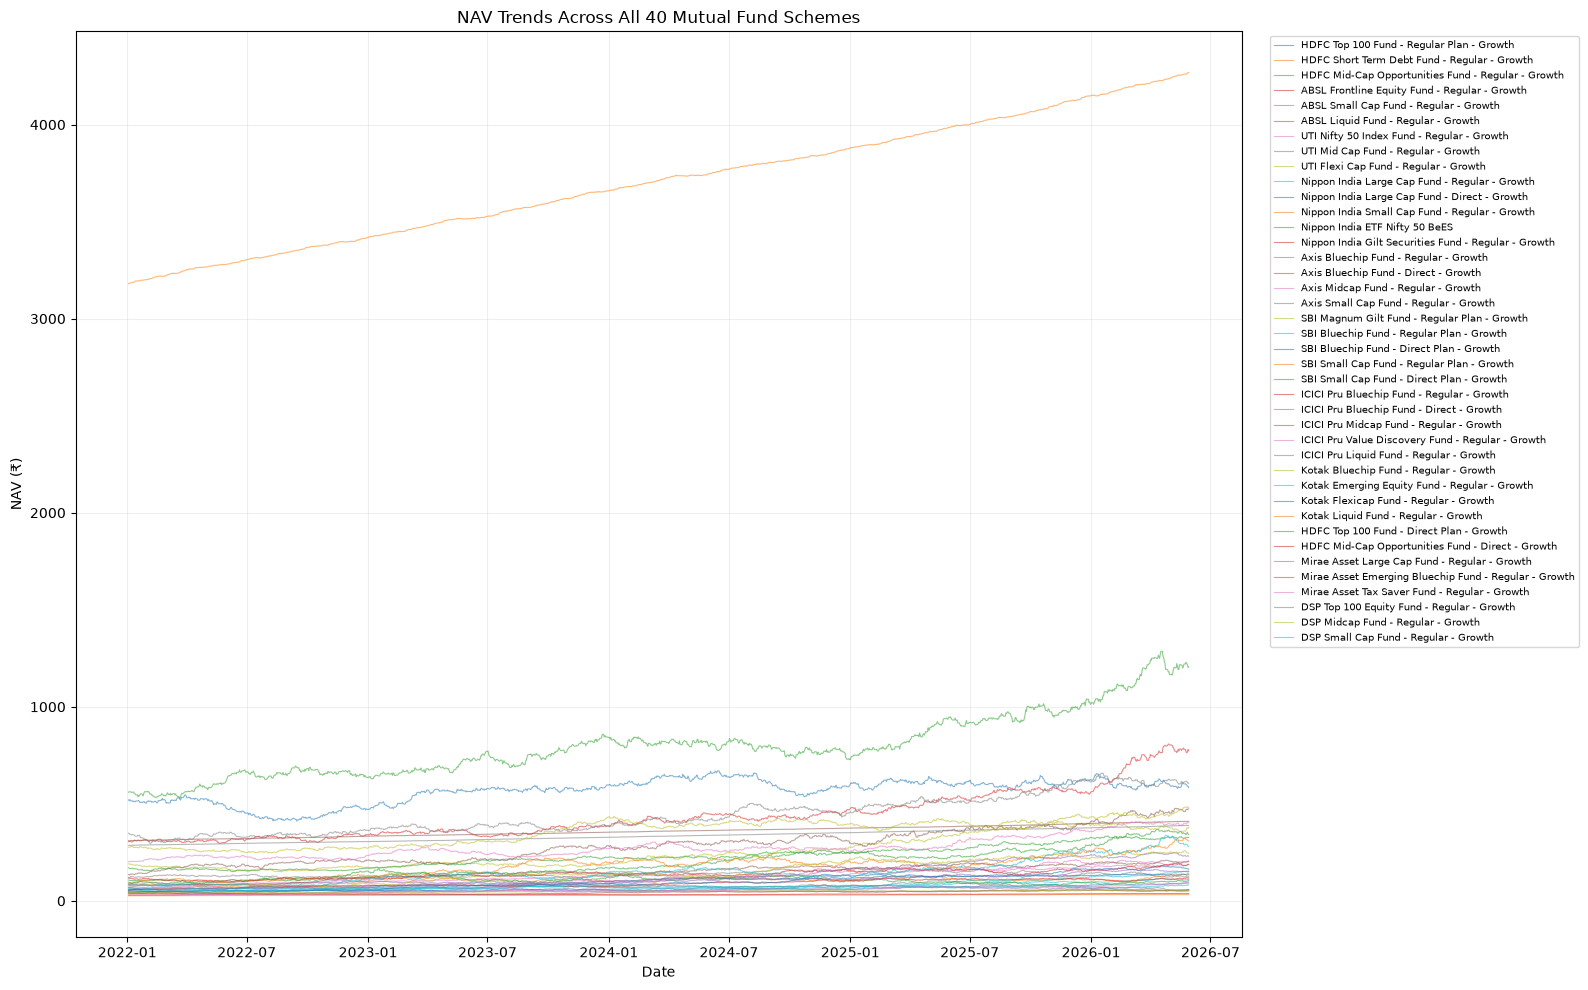

Number of schemes plotted: 40
Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_nav_trends_all_40_schemes.png


In [ ]:
# ============================================================
# Chart 26 — NAV Trends Across All 40 Schemes
# ============================================================

plt.figure(figsize=(16, 10))

for code, group in nav_history.groupby("amfi_code"):
    group = group.sort_values("date")
    
    scheme_name = code_to_name.get(code, str(code))
    
    plt.plot(
        group["date"],
        group["nav"],
        linewidth=0.8,
        alpha=0.55,
        label=scheme_name
    )

plt.title("NAV Trends Across All 40 Mutual Fund Schemes")
plt.xlabel("Date")
plt.ylabel("NAV (₹)")
plt.grid(alpha=0.2)

# Keep legend outside the plot
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=7
)

plt.tight_layout()

chart_path = REPORTS_DIR / "eda_nav_trends_all_40_schemes.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Number of schemes plotted:", nav_history["amfi_code"].nunique())
print("Chart saved to:", chart_path)

Year-end AUM (₹ crore):
fund_house  Aditya Birla Sun Life MF  Axis Mutual Fund  DSP Mutual Fund  \
year                                                                      
2022                          285000            240000           112000   
2023                          308000            260000           132000   
2024                          384000            300000           188000   
2025                          460000            350000           230000   

fund_house  HDFC Mutual Fund  ICICI Prudential MF  Kotak Mahindra MF  \
year                                                                   
2022                  445000               488000             272000   
2023                  535000               590000             325000   
2024                  787000               874000             489000   
2025                  930000              1074000             580000   

fund_house  Mirae Asset MF  Nippon India MF  SBI Mutual Fund  UTI Mutual Fund  
year        

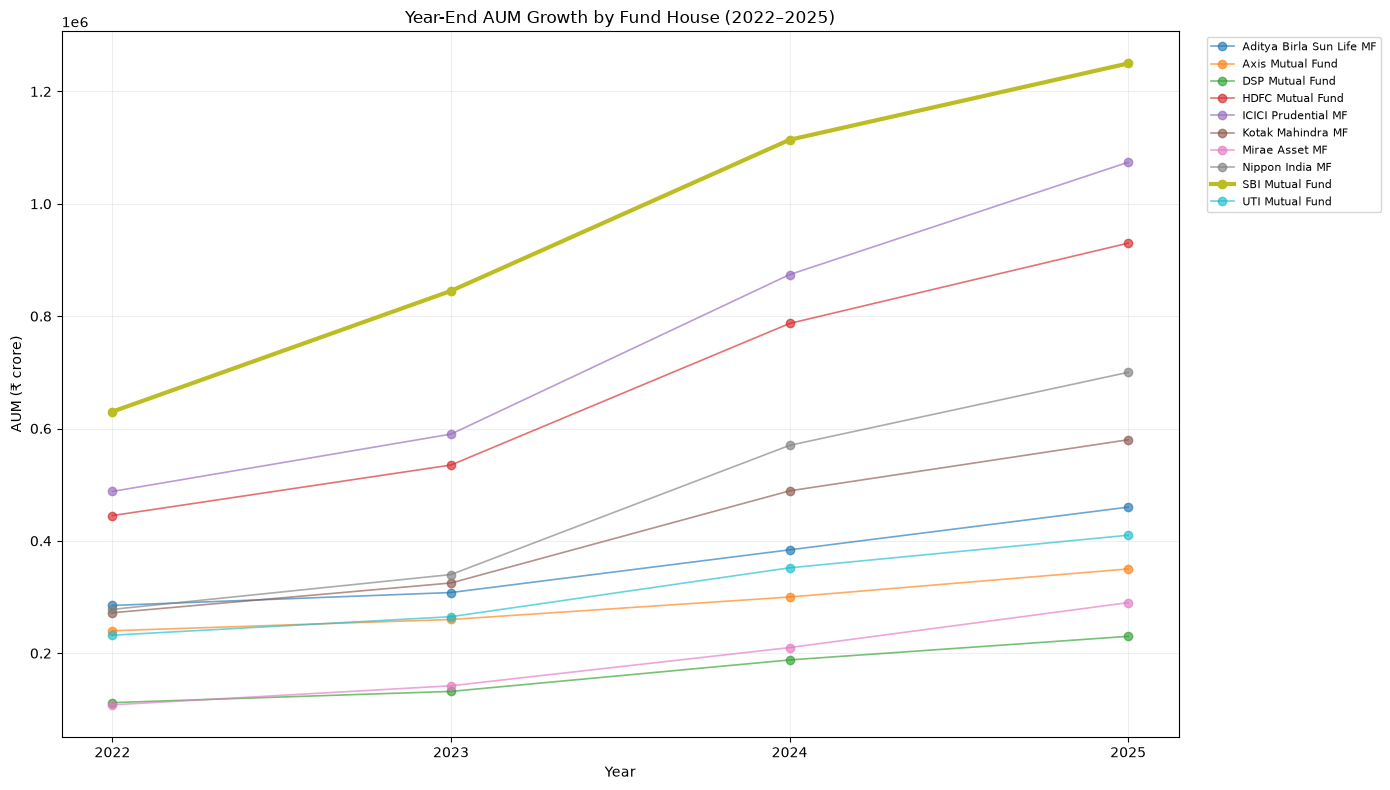


Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_aum_growth_by_fund_house_year.png


In [ ]:
# ============================================================
# Chart 27 — AUM Growth by Fund House (2022–2025)
# ============================================================

# Prepare AUM data
aum_yearly = aum.copy()

aum_yearly["date"] = pd.to_datetime(aum_yearly["date"])
aum_yearly["year"] = aum_yearly["date"].dt.year

# Keep 2022–2025
aum_yearly = aum_yearly[
    aum_yearly["year"].between(2022, 2025)
].copy()

# Take the latest AUM observation for each fund house in each year
aum_year_end = (
    aum_yearly
    .sort_values("date")
    .groupby(["fund_house", "year"], as_index=False)
    .last()
)

# Pivot for easier inspection
aum_pivot = aum_year_end.pivot(
    index="year",
    columns="fund_house",
    values="aum_crore"
)

print("Year-end AUM (₹ crore):")
print(aum_pivot.round(0))

# Plot
plt.figure(figsize=(14, 8))

for fund_house in aum_pivot.columns:
    if "SBI" in fund_house.upper():
        plt.plot(
            aum_pivot.index,
            aum_pivot[fund_house],
            marker="o",
            linewidth=3,
            label=fund_house
        )
    else:
        plt.plot(
            aum_pivot.index,
            aum_pivot[fund_house],
            marker="o",
            linewidth=1.2,
            alpha=0.65,
            label=fund_house
        )

plt.title("Year-End AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ crore)")
plt.xticks([2022, 2023, 2024, 2025])
plt.grid(alpha=0.2)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

chart_path = REPORTS_DIR / "eda_aum_growth_by_fund_house_year.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("\nChart saved to:", chart_path)

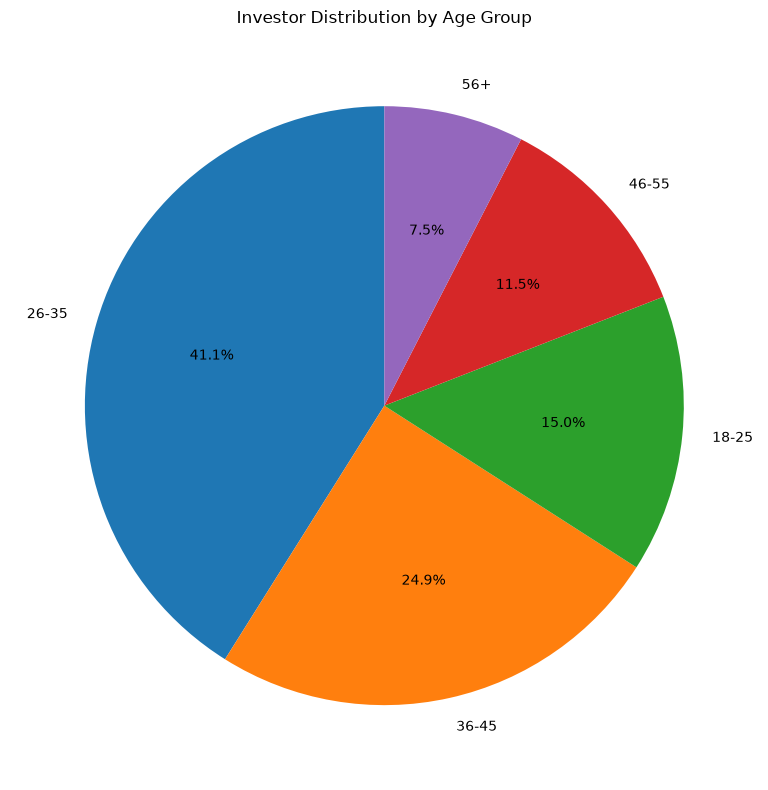

Age group transaction counts:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_age_group_pie.png


In [ ]:
# ============================================================
# Chart 28 — Investor Age Group Distribution
# ============================================================

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.tight_layout()

chart_path = REPORTS_DIR / "eda_age_group_pie.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Age group transaction counts:")
print(age_counts)

print("\nChart saved to:", chart_path)

SIP transactions: 19716
Total SIP amount (₹): 217233491


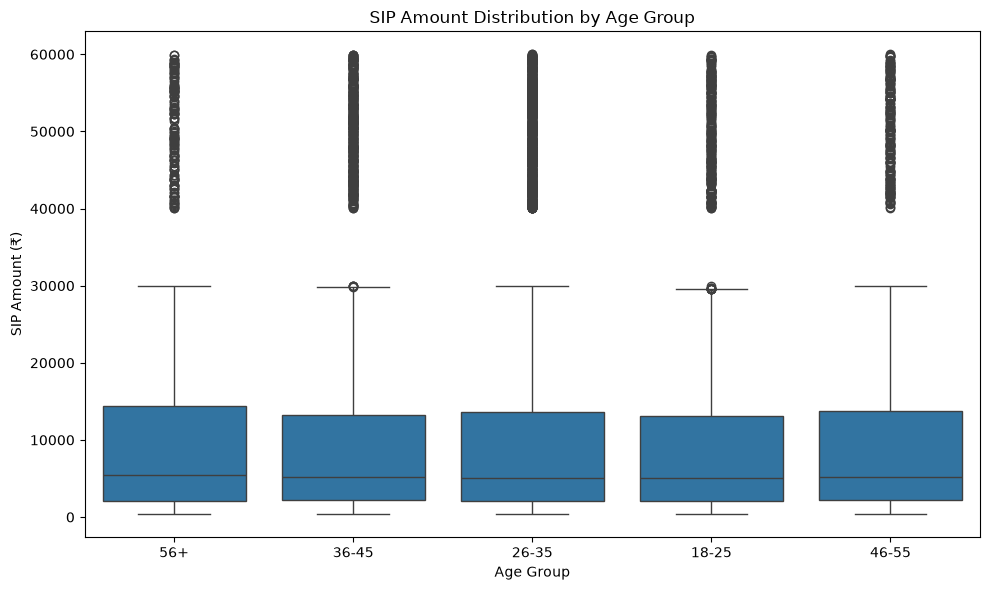

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_sip_amount_by_age_boxplot.png


In [ ]:
# ============================================================
# Chart 29 — SIP Amount Distribution by Age Group
# ============================================================

# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

# Check the data
print("SIP transactions:", len(sip_transactions))
print("Total SIP amount (₹):", sip_transactions["amount_inr"].sum())

# Box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()

chart_path = REPORTS_DIR / "eda_sip_amount_by_age_boxplot.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

SIP amount by state (₹):
state
Maharashtra       16445629
Rajasthan         16544233
Delhi             17113608
West Bengal       17495769
Uttar Pradesh     17534858
Karnataka         17696903
Haryana           18176696
Gujarat           18378904
Tamil Nadu        18404368
Telangana         18620216
Punjab            20140064
Madhya Pradesh    20682243
Name: amount_inr, dtype: int64


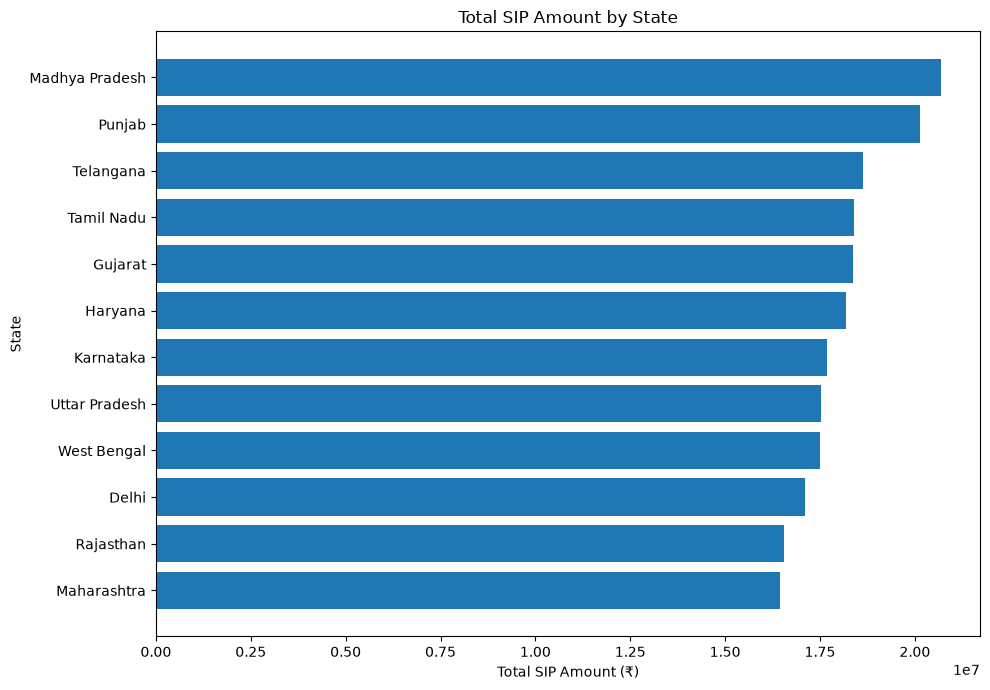


Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_sip_amount_by_state.png


In [ ]:
# ============================================================
# Chart 30 — SIP Amount by State
# ============================================================

# Keep only SIP transactions
sip_by_state = (
    transactions[
        transactions["transaction_type"].str.upper() == "SIP"
    ]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

print("SIP amount by state (₹):")
print(sip_by_state)

# Horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    sip_by_state.index,
    sip_by_state.values
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

chart_path = REPORTS_DIR / "eda_sip_amount_by_state.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("\nChart saved to:", chart_path)

SIP amount by city tier (₹):
city_tier
T30    144928621
B30     72304870
Name: amount_inr, dtype: int64


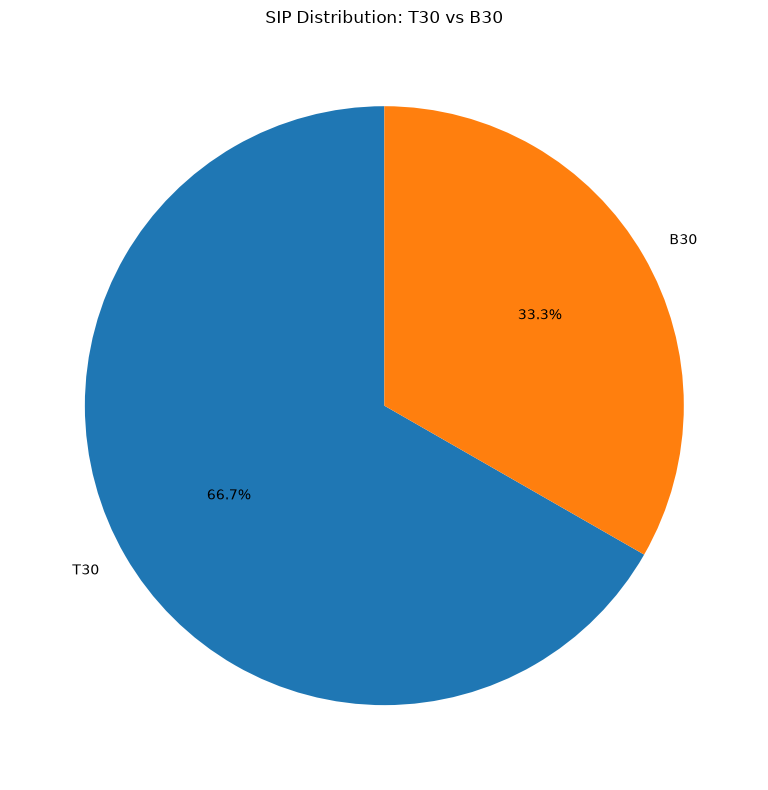


Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\eda_t30_b30_sip_distribution.png


In [ ]:
# ============================================================
# Chart 31 — T30 vs B30 SIP Distribution
# ============================================================

# Keep only SIP transactions
sip_t30_b30 = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

# Aggregate SIP amount by city tier
tier_sip = (
    sip_t30_b30
    .groupby("city_tier")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("SIP amount by city tier (₹):")
print(tier_sip)

# Pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    tier_sip.values,
    labels=tier_sip.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("SIP Distribution: T30 vs B30")

plt.tight_layout()

chart_path = REPORTS_DIR / "eda_t30_b30_sip_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("\nChart saved to:", chart_path)